<a href="https://colab.research.google.com/github/Bassendiaye/mes_notebooks/blob/main/Macenko.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
from sklearn.decomposition import PCA

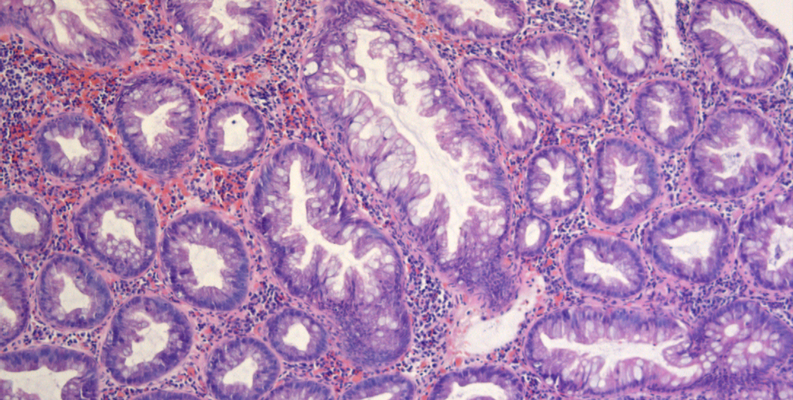

In [ ]:
from google.colab.patches import cv2_imshow

image_path = "dataset-cover.png"
img = cv2.imread(image_path)
cv2_imshow(img)

In [ ]:
def rgb_to_od(img):
    img = img.astype(np.float32)
    img[img == 0] = 1  # Avoid division by zero
    return -np.log(img / 255)

img_od = rgb_to_od(img)

In [ ]:
reshaped_od = img_od.reshape((-1, 3))
pca = PCA(n_components=2)
pca.fit(reshaped_od)
stain_matrix = pca.components_.T

In [ ]:
stains = np.dot(reshaped_od, np.linalg.pinv(stain_matrix).T)

In [ ]:
stains = stains.reshape(img.shape[0], img.shape[1], -1)

In [ ]:
target_means = np.array([0.5, 0.5])
target_stds = np.array([0.2, 0.2])
stains_normalized = (stains - np.mean(stains, axis=(0, 1))) / np.std(stains, axis=(0, 1))
stains_normalized = stains_normalized * target_stds + target_means

In [ ]:
od_normalized = np.dot(stains_normalized.reshape((-1, 2)), stain_matrix.T)
od_normalized = od_normalized.reshape(img.shape)
img_reconstructed = np.exp(-od_normalized)

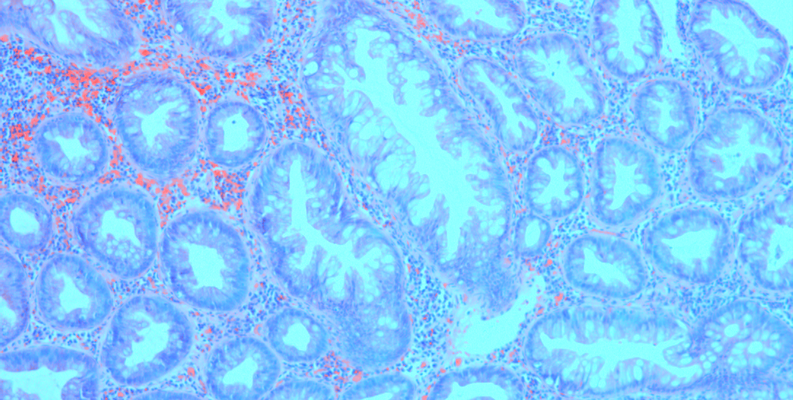

In [ ]:
img_reconstructed = np.clip(img_reconstructed, 0, 1)
img_reconstructed = (img_reconstructed * 255).astype(np.uint8)
cv2_imshow(img_reconstructed)